In [ ]:
!git clone https://github.com/Break-Through-Tech/Google-2E-faithfulmed-a-multi-agent-system-for-faithful-patient-friendly-medical-explanations.git


fatal: destination path 'Google-2E-faithfulmed-a-multi-agent-system-for-faithful-patient-friendly-medical-explanations' already exists and is not an empty directory.


In [ ]:
!ls sample_data


anscombe.json		      medaesqa_v1.json
california_housing_test.csv   mnist_test.csv
california_housing_train.csv  mnist_train_small.csv
MedAESQA_methods_M1-M30.xlsx  README.md


##Loading MedAESQA

In [ ]:
import json

with open("sample_data/medaesqa_v1.json", "r") as f:
    medaesqa = json.load(f)

print("Number of questions:", len(medaesqa))

Number of questions: 40


In [ ]:
print(medaesqa[0].keys())

dict_keys(['question_id', 'question', 'question_frame', 'expert_curated_answer', 'machine_generated_answers', 'nuggets'])


##Inspecting First Record

In [22]:
first = medaesqa[0]

print("Question ID:")
print(first["question_id"])

print("\nQuestion:")
print(first["question"])

print("\nExpert Answer:")
print(first["expert_curated_answer"])

Question ID:
116

Question:
Are there ways to prevent sleep apnea or treat it naturally?

Expert Answer:
 There are ways to prevent and treat sleep apnea naturally. Lifestyle changes may prevent and treat sleep apnea [28646811, 33659106, 28659501, 12693795, 36617387]. Sleep apnea can be prevented by losing weight and keeping it down with diet and exercise [33659106, 12693795, 30204000, 36617387, 28659501]; quitting alcohol and smoking [33659106, 12693795, 36617387]; and changing sleep position [12693795, 22987061, 30204000, 36617387]. While Continuous Positive Airway Pressure (CPAP, a machine that uses mild air pressure to keep breathing airways open while you sleep) is the standard treatment for obstructive sleep apnea (OSA) [28901030, 35909585], Chinese massage Tui Na [28646811], dental treatments to change teeth and jaw position [12693795, 36617387, 28901030]; and exercises for tongue and throat [28901030] reduce snoring and apnea. Treatments with drugs [30204000, 22987061], nerve s

In [23]:
machine_answers = first["machine_generated_answers"]

print("Number of machine answers:", len(machine_answers))
print("Machine answer IDs:", list(machine_answers.keys()))

Number of machine answers: 30
Machine answer IDs: ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'M10', 'M11', 'M12', 'M13', 'M14', 'M15', 'M16', 'M17', 'M18', 'M19', 'M20', 'M21', 'M22', 'M23', 'M24', 'M25', 'M26', 'M27', 'M28', 'M29', 'M30']


In [24]:
print(machine_answers["M1"].keys())

dict_keys(['answer', 'is_answer_accurate', 'answer_sentences'])


In [25]:
print("M1 answer:")
print(machine_answers["M1"]["answer"])

print("\nHuman accuracy judgment:")
print(machine_answers["M1"]["is_answer_accurate"])

M1 answer:
There are several natural ways to prevent and treat sleep apnea [22014867]. Lifestyle modifications such as weight loss, avoiding alcohol and sedatives, and sleeping on one's side can help alleviate symptoms [28126502, 14971838, 15162258]. Dietary modifications, such as those described in a case report of a 55-year-old man who no longer required a CPAP device after adhering to dietary changes for 3 months, may also be effective [22014867]. Additionally, oral appliances, conditioning to avoid the supine sleeping position, and inclined pillows can be used to treat mild to moderate sleep apnea [28126502, 30204000, 15162258]. Furthermore, alternative treatments such as hypoglossal nerve stimulation, body positioning, and oxygen treatment may also be effective [28126502, 30204000, 27134515]. It is essential to note that while these natural methods can be helpful, they may not be as effective as continuous positive airway pressure (CPAP) therapy, which is the gold standard treatme

In [28]:
import pandas as pd
accuracy_labels = []

for question in medaesqa:
    for model_id, answer_info in question["machine_generated_answers"].items():
        accuracy_labels.append(answer_info["is_answer_accurate"])

accuracy_counts = pd.Series(accuracy_labels).value_counts()

print(accuracy_counts)

yes    1102
no       98
Name: count, dtype: int64


In [29]:
print("\nPercentages:")
print(
    pd.Series(accuracy_labels)
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


Percentages:
yes    91.83
no      8.17
Name: proportion, dtype: float64


MedAESQA contains 1,200 machine-generated answers. 91.83%(1102) were judged accurate and 8.17%(98) were judged inaccurate.

I started by loading MedAESQA and confirmed that it has 40 health questions. Each question has 30 machine-generated answers, giving us 1,200 machine answers in total. I then looked at the human accuracy labels. About 91.8% of the answers were judged accurate and only 8.2% were inaccurate, so there's quite a large class imbalance. That's something we'll have to consider when we eventually evaluate our Verifier.

##Visualizing the Accuracy

NameError: name 'plt' is not defined

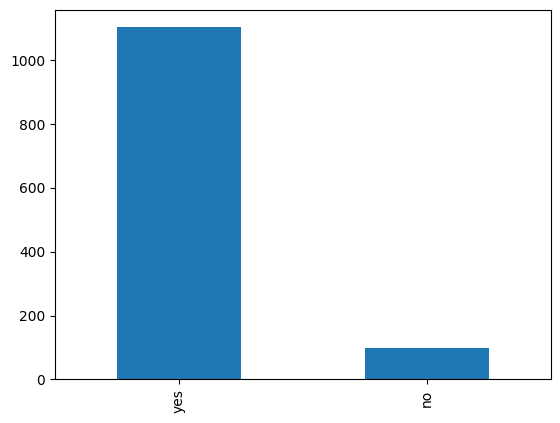

In [30]:
accuracy_counts.plot(kind="bar")

plt.title("Human Accuracy Judgments in MedAESQA")
plt.xlabel("Accuracy Label")
plt.ylabel("Number of Machine Answers")
plt.show()

##Looking at the first "no" inacurate

In [31]:
for question in medaesqa:
    for model_id, answer_info in question["machine_generated_answers"].items():

        if answer_info["is_answer_accurate"].lower() == "no":

            print("QUESTION:")
            print(question["question"])

            print("\nMODEL:")
            print(model_id)

            print("\nMACHINE ANSWER:")
            print(answer_info["answer"])

            print("\nACCURATE:")
            print(answer_info["is_answer_accurate"])

            break
    else:
        continue
    break

QUESTION:
Are there ways to prevent sleep apnea or treat it naturally?

MODEL:
M5

MACHINE ANSWER:
There is no natural way to prevent sleep apnea. Treatment options for sleep apnea in children include adenotonsillectomy, which is the first line treatment, but improvement in objectively documented outcomes is often inadequate and a substantial number of children have residual disease [28052557]. A multidisciplinary approach is required as most of them have additional risk factors for sleep apnea and comorbidities [28052557]. Different diagnostic modalities are available to evaluate the sites of persistent upper airway obstruction and currently available treatment options are discussed in the literature [28052557].

ACCURATE:
no


M5 gave an inaccurate esponse to the question.

Looking at MedAESQ was important for us to understand that our Faithful Med should have a verifer that should work and detect these errors so that they do not give inaccuare responses to querries.

In [21]:
import os
from google import genai
from google.colab import userdata

# Get API key securely from Colab Secrets
api_key = userdata.get("GEMINI_API_KEY")

# Create Gemini client
client = genai.Client(api_key=api_key)

# Make a simple test request
response = client.models.generate_content(
    model="gemini-3.7-flash",
    contents="Say: FaithfulMed Gemini setup successful!"
)

print(response.text)

TimeoutException: Requesting secret GEMINI_API_KEY timed out. Secrets can only be fetched when running from the Colab UI.

In [ ]:
%cd /content/Google-2E-faithfulmed-a-multi-agent-system-for-faithful-patient-friendly-medical-explanations

In [ ]:
!cat data/README.md

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!ls

In [ ]:
!pip install -r requirements.txt